# 파이썬 머신러닝 완벽가이드 (교재정리)

## 1. 회귀 소개

* 회귀분석은 데이터 값이 평균과 같은 일정한 값으로 돌아가려는 경향을 이용한 통계학 기법

**통계학 관점**    
    
* 통계학 용어로 설명하면 회귀는 여러 개의 독립변수와 한 개의 종속변수 간의 상관관계를 모델링하는 기법을 통칭한다.
* 아파트가격으로 예제만들기
  * Y는 아파트가격으로 종속변수
  * X1, X2, X3 등은 방 개수, 방 크기, 주변 학군, 인프라 등의 독립변수
  * W1, W2, W3 등은 이 독립변수의 값에 영향을 미치는 회귀 계수 (Regression coefficients)

**머신러닝 관점**    
    
* 독립변수는 피처
* 종속변수는 결정값
* 머신러닝 회귀 예측의 핵심은 주어진 피처와 결정 값 데이터 기반에서 학습을 통해 최적의 회귀 계수를 찾아내는 것.

**회귀의 유형**

* 회귀는 여러가지 유형으로 나눌 수 있는데 가장 중요한것은 바로 회귀 계수이다.
* 이 회귀 계수가 선형이나 아니냐에 따라 선형 회귀와 비선형 회귀로 나뉜다.
* 그리고 독립변수의 개수가 한 개인지 여러개인지에 따라 단일 회귀, 다중회귀로 나뉜다.

* 회귀 중에서 선형 회귀가 가장 많이 사용된다.
---
* 대표적인 선형회귀 모델
  * 일반 선형 회귀
  * 릿지
  * 라쏘
  * 엘리스틱넷
  * 로지스틱 회귀

## 2. 단순 선형 회귀를 통한 회귀 이해

* 단순 선형 회귀는 독립변수도 하나, 종속변수도 하나인 선형 회귀이다.
* 실제 값과 회귀 모델의 차이에 따른 오류 값을 남은 오류 = 잔차 라고 부른다.
* 최적의 회귀 모델을 만든다는것은 전체 데이터의 잔차 합이 최소가 되는 모델을 만든다는 의미
* 동시에 오류 값 합이 최소가 될 수 있는 최적의 회귀 계수를 찾는다는 의미도 된다.

## 3. 비용 최소화하기 - 경사 하강법 (Gradient Descent) 소개

* 책에 정리된 수식과 절차를 이용하여 경사 하강법을 파이썬 코드로 구현하기
* 간단한 회귀식인 y = 4X + 6을 근사하기 위한 100개의 데이터 세트를 만든다.
* 여기에 경사 하강법을 이용해 회구계수 w1, w0을 도출하기

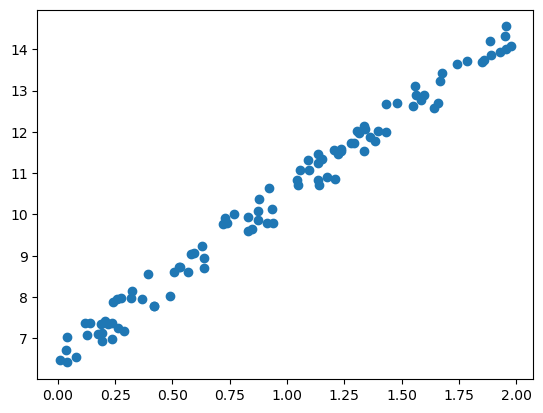

In [1]:
# 데이터 세트 만들기

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)

#y = 4X + 6을 근사 (w1 = 4, w0 = 6) 임의의 값은 노이즈를 위해 만듦
X = 2 * np.random.rand(100, 1)
y = 6 + 4 * X + np.random.rand(100, 1)

# X, y 데이터 세트 산점도로 시각화
plt.scatter(X,y)
plt.show()

* 결과 : 데이터는 y = 4X + 6을 중심으로 무작위로 퍼져있다.
* 다음은 비용 함수를 정의해 보겠습니다.
* 비용 함수 get_cost()는 실제 y값과 예측된 y값을 인자로 받아 (실제값i - 예측값i)제곱 을 계산해 반환합니다.

In [2]:
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred)) / N

    return cost

* 이제 경사 하강법을 gradient_descent()라는 함수를 생성해 구현해보기

In [3]:
# w1과 w0을 업데이트할 w1_update, w0_update를 반환
def get_weight_updates(w1, w0, X, y, learning_rate = 0.01):
    N = len(y)

    #먼저 wq_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0 값으로 초기화
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)

    #예측 배열 계산하고 예측과 실제 값의 차이 계산
    y_pred = np.dot(X, w1.T) + w0
    diff = y - y_pred

    # w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
    w0_factors = np.ones((N, 1))

    #w1과 w0을 업데이트할 w1_update와 w0_update 계산
    w1_update = -(2/N) * learning_rate * (np.dot(X.T, diff))
    w0_update = -(2/N) * learning_rate * (np.dot(w0_factors.T, diff))

    return w1_update, w0_update

* 다음은 get_weight_update()을 경사 하강 방식으로 반복적으로 수행하여
* w1 w0를 업데이트하는 한수인 gradient_descent_sreps() 함수를 생성하겠습니다.

In [4]:
# 입력인사 iters로 주어진 횟수만큼 반복적으로 w1과 w0를 업데이트 적용함.
def gradient_descent_steps(X, y, iters = 10000):
    
    # w0와 w1을 모두 0으로 초기화
    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))

    # 인자로 주어진 iters 만큼 반복적으로 get_weight_updates() 호출해 w1, w0 업데이트 수행.
    for ind in range(iters):
        w1_update, w0_update = get_weight_updates(w1, w0, X, y, learning_rate = 0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update

    return w1, w0

* 이제 gradient_descent_steps()를 호출해 w1과 w0을 구해보겠습니다.
* 그리고 최종적으로 예측값과 실제값의 RSS 차이를 계산하는 get_cost()함수를 생성하겠습니다.
* 위를 이용하여 하강법의 예측 오류도 계산해보겠습니다.

In [5]:
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred)) / N
    return cost

w1, w0 = gradient_descent_steps(X, y, iters = 1000)
print("w1 : {0:.3f} w0:{1:.3f}".format(w1[0,0], w0[0,0]))

y_pred = w1[0, 0] * X + w0
print('Gradient Descent Total Cost : {0:.4f}'.format(get_cost(y, y_pred)))

w1 : 4.028 w0:6.490
Gradient Descent Total Cost : 0.0775


* 위에서 구한 y_pred에 기반해 회귀선을 그려보기

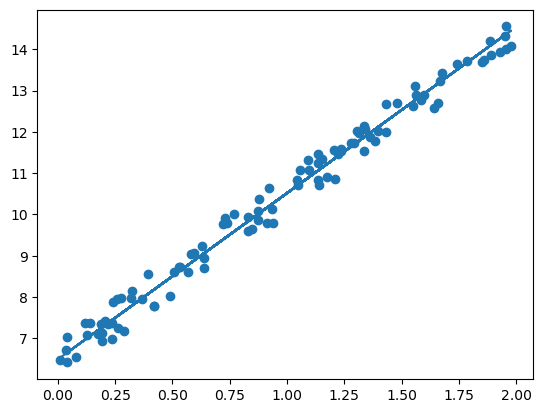

In [6]:
plt.scatter(X, y)
plt.plot(X, y_pred)

plt.show()

* 경사 하강법을 이용해 회귀선이 잘 만들어졌음을 알 수 있습니다.
* 일반적으로 경사 하강법은 모든 학습 데이터에 대해 반복적으로 비용함수 최소화를 위한 값을 업데이트하기 때문에 수행 시간이 매우 오래 걸린다는 단점이 있습니다.
* 위 같은 이유로 실전에서는 대부분 확률적 경사 하강법을 이용합니다.
* **미니 배치 확률적 경사 하강법을 stochastic_gradient_descent_steps() 함수로 구현해 보겠습니다.**

In [7]:
def stochastic_gradient_descent_steps(X, y, batch_size=10, iters=1000):
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    prev_cost = 100000
    iter_index =0
    
    for ind in range(iters):
        np.random.seed(ind)
        # 전체 X, y 데이터에서 랜덤하게 batch_size만큼 데이터 추출하여 sample_X, sample_y로 저장
        stochastic_random_index = np.random.permutation(X.shape[0])
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]
        # 랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 후 업데이트
        w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
    
    return w1, w0

위처럼 만들어진 Stochastic_gradient_descent_steps()를 이용해 w1, w0 및 예측 오류 비용을 계산해보겠습니다.

In [8]:
w1, w0 = stochastic_gradient_descent_steps(X, y, iters=1000)
print("w1:",round(w1[0,0],3),"w0:",round(w0[0,0],3))
y_pred = w1[0,0] * X + w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1: 4.031 w0: 6.486
Stochastic Gradient Descent Total Cost:0.0777


* **결과**

확률적 경사 하강법으로 구한 w0, w1 결과는 경사 하강법으로 구한 w1, w0와 큰 차이가 없으며,    
예측 오류 비용 또한 0.9937로 경사 하강법으로 구한 예측 오류 비용 0.9935보다 아주 조금 높을 뿐으로    
큰 예측 성능상의 차이가 없음을 알 수 있습니다. 따라서 큰 데이터를 처리 할 경우에는         
**경사 하강법은 매우 시간이 오래 걸리므로 일반적으로 확률적 경사 하강법을 이용합니다.**

## 4. 사이킥런 LinearRegression을 이용한 보스턴 주택 가격 예측

### LinearRegression 클래스 = Ordinary Least Squares

* LinearRegression 클래스는 예측값과 실제 값의 RSS(Residual Sum of Squares)를 최소화해    
* OLS(Ordinary Least Squares) 추정 방식으로 구현한 클래스 입니다.

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=True, 
                         copy_X=True, 
                         n_jobs=1)  # normalize 제거됨

* fit_intercept : 불린 값으로 디폴트는 True , Intercept(절편) 값을 계산할 것이닞 말지를 지정합니다. 만일 False로 지정하면 intercept가 사용되지 않고 0으로 지정됩니다.
* momalize = normalize 파라미터는 Scikit-learn 1.0에서 deprecated 되었고, 1.2 버전부터는 완전히 제거되었습니다.
* coef_ : fit() 메서드를 수행했을 때 회귀 계수가 배열 형태로 저장하는 속성. shape는 (Target 값 계수, 피처 개수)
* intercept_ : intercept 값

### 회귀 평가 지표

- MAE : Mean Absolute Error 실제 값과 예측값의 차이를 절댓값으로 변환해 평균한것
- MSE : Mean squared Error 실제 값과 예측값의 차이를 제곱해 평균한것
- RMSE : MSE 값은 로유의 제곱을 구하므로 실제 오류 평균보다 더 커지는 특성이 있으므로 MSE에 루트를 씌운것이 RMSE입니다.
- 이 밖에 MSE나 RMSE에 로그를 적용한 MSLE(Mean Squared Log Error), RMSLE(Root Mean Squared Log Error)도 사용한다.

## LinearRegression을 이용해 보스턴 주택 가격 회귀 구현

* LinearRegression 클래스를 이용해 선형 회귀 모델 만들어보기
* 내장된 bosston 주택 가격 데이터를 이용할 예정

* 피처 설명
    * CRIM: 지역별 범죄 발생률
    * ZN: 25,000평방피트를 초과하는 거주 지역의 비율
    * NDUS: 비상업 지역 넓이 비율
    * CHAS: 찰스강에 대한 더미 변수(강의 경계에 위치한 경우는 1, 아니면 0)
    * NOX: 일산화질소 농도
    * RM: 거주할 수 있는 방 개수
    * AGE: 1940년 이전에 건축된 소유 주택의 비율
    * DIS: 5개 주요 고용센터까지의 가중 거리
    * RAD: 고속도로 접근 용이도
    * TAX: 10,000달러당 재산세율
    * PTRATIO: 지역의 교사와 학생 수 비율
    * B: 지역의 흑인 거주 비율
    * LSTAT: 하위 계층의 비율
    * MEDV: 본인 소유의 주택 가격(중앙값) 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')  #사이킷런 1.2 부터는 보스턴 주택가격 데이터가 없어진다는 warning 메시지 출력 제거
%matplotlib inline

# boston 데이타셋 로드
boston = fetch_openml(name='boston')

# boston 데이타셋 DataFrame 변환 
bostonDF = pd.DataFrame(boston.data , columns = boston.feature_names)

# 카데고리 데이터 수치형으로 변환
bostonDF['RAD'] = pd.to_numeric(bostonDF['RAD'], errors='coerce')
bostonDF['CHAS'] = pd.to_numeric(bostonDF['CHAS'], errors='coerce')

# boston dataset의 target array는 주택 가격임. 이를 PRICE 컬럼으로 DataFrame에 추가함. 
bostonDF['PRICE'] = boston.target
print('Boston 데이타셋 크기 :',bostonDF.shape)
bostonDF.head()

Boston 데이타셋 크기 : (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


* 데이터 세트 피처의 Null 값은 없으며 모두 float 형입니다.

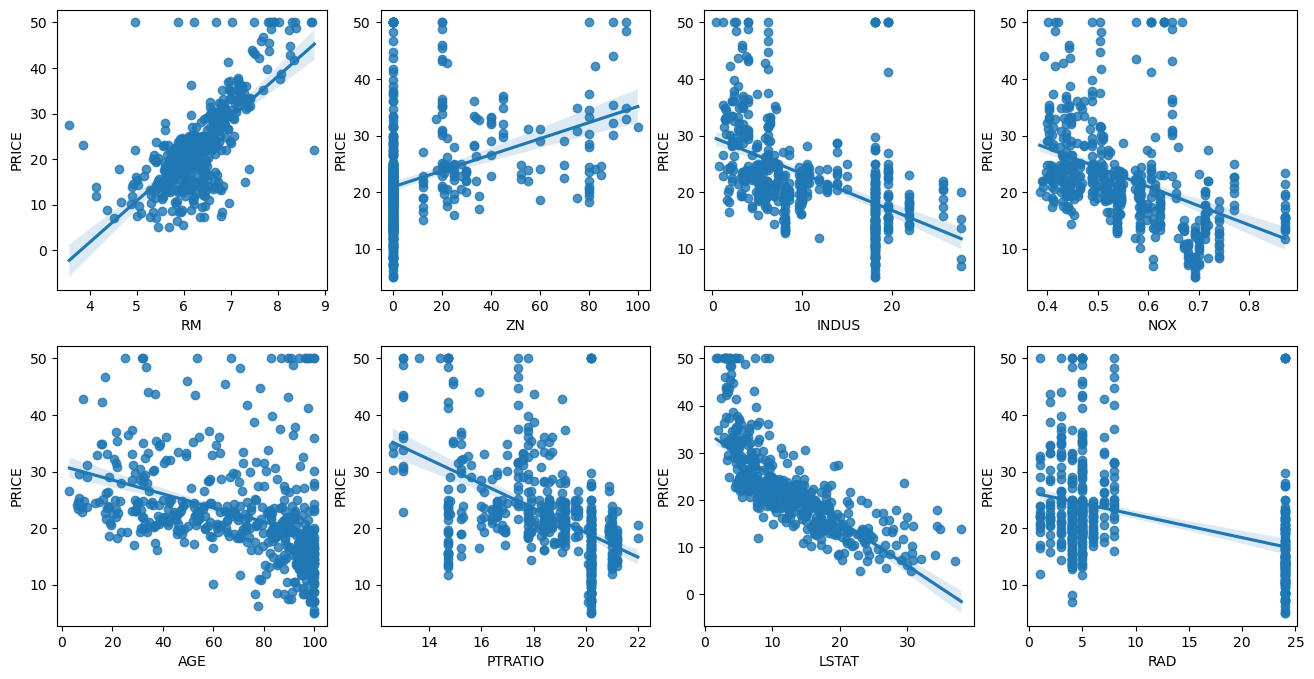

In [18]:
# 2개의 행과 4개의 열을 가진 subplots를 이용. axs는 4x2개의 ax를 가짐.
fig, axs = plt.subplots(figsize=(16,8) , ncols=4 , nrows=2)
lm_features = ['RM','ZN','INDUS','NOX','AGE','PTRATIO','LSTAT','RAD']
for i , feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    # 시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
    sns.regplot(x=feature , y='PRICE',data=bostonDF , ax=axs[row][col])

fig1 = plt.gcf()
fig1.savefig('p322_boston.tif', format='tif', dpi=300, bbox_inches='tight')

plt.show()

* RM과 LSTA의 PRICE 영향도가 가장 두드러지게 나타난다.
* RM(방 개수) 양 방향의 선형성(Positive Linearity)이 가장 큽니다.    
  이것은 방의 크기가 클수록 가격이 증가하는 모습을 확인히 보여줍니다.
* LSTAT(하위 계층의 비율) 음 방향의 선형성(Negative Linearity)이 가장 큽니다.    
  LSTAT이 적을 수록 PRICE가 증가됩니다.

**학습과 테스트 데이터 세트로 분리하고 학습/예측/평가 수행**

In [19]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'],axis=1,inplace=False)

X_train , X_test , y_train , y_test = train_test_split(X_data , y_target ,test_size=0.3, random_state=156)

# Linear Regression OLS로 학습/예측/평가 수행. 
lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds = lr.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f} , RMSE : {1:.3F}'.format(mse , rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))

MSE : 17.297 , RMSE : 4.159
Variance score : 0.757


In [22]:
print('절편 값:', lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_, 1))

절편 값: 40.99559517216436
회귀 계수값: [ -0.1   0.1   0.    3.  -19.8   3.4   0.   -1.7   0.4  -0.   -0.9   0.
  -0.6]


coef_ 속성은 회귀 계수 값만 가지고 있으므로 이를 피처별 회귀 계수 값으로 다시 매핑하고 높은 값 순으로 출력하기

In [21]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. index가 칼럼명에 유의
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns )
coeff.sort_values(ascending=False)

RM          3.4
CHAS        3.0
RAD         0.4
ZN          0.1
INDUS       0.0
AGE         0.0
TAX        -0.0
B           0.0
CRIM       -0.1
LSTAT      -0.6
PTRATIO    -0.9
DIS        -1.7
NOX       -19.8
dtype: float64

* RM의 양의 값으로 회귀 계수가 가장 크며, NOX 피처의 회귀 계수 - 값이 너무 커 보입니다.
* 차츰 최적화를 수행하면서 피처 coefifcients의 변화도 같이 살펴보기

In [23]:
from sklearn.model_selection import cross_val_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'],axis=1,inplace=False)
lr = LinearRegression()

# cross_val_score( )로 5 Fold 셋으로 MSE 를 구한 뒤 이를 기반으로 다시  RMSE 구함. 
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv = 5)
rmse_scores  = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring="neg_mean_squared_error")로 반환된 값은 모두 음수 
print(' 5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5 folds 의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(' 5 folds 의 평균 RMSE : {0:.3f} '.format(avg_rmse))

 5 folds 의 개별 Negative MSE scores:  [-12.46 -26.05 -33.07 -80.76 -33.31]
 5 folds 의 개별 RMSE scores :  [3.53 5.1  5.75 8.99 5.77]
 5 folds 의 평균 RMSE : 5.829 


* 5개 폴드 세트에 대해서 교차 검증을 수행한 결과, 평균 RMSE는 약 5.829가 나왔습니다.
* cross_val_score( scoring = "neg_mean_squared_error")로 반환된 값을 확인해 보면 모두 음수임을 알 수 있다.

## 다항 회귀와 과(대)적합 / 과소적합 이해

### 다항 회귀 이해

**PolynomialFeatures를 이용해 단항값을 2차 다항값으로로 변환하는 예제**

In [24]:

from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 다항식으로 변환한 단항식 생성, [[0,1],[2,3]]의 2X2 행렬 생성
X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature:\n',X )

# degree = 2 인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이용하여 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 feature:\n', poly_ftr)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 feature:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


* 3차 다항식 결정값을 구하는 함수 polynomial_func(X) 생성. 즉 회귀식은 결정값 y = 1+ 2x_1 + 3x_1^2 + 4x_2^3

In [25]:
def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    print(X[:, 0])
    print(X[:, 1])
    return y

X = np.arange(0,4).reshape(2,2)

print('일차 단항식 계수 feature: \n' ,X)
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
[0 2]
[1 3]
삼차 다항식 결정값: 
 [  5 125]


* 일차 단항식 계수를 삼차 다항식 계수로 변환하고
* 이를 선형 회귀에 적용하면 다항 회귀로 구현됩니다.
* 3차 다항식 계수의 피처값과 3차 다항식 결정값으로 학습

In [26]:
# 3 차 다항식 변환 
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n',poly_ftr)

# Linear Regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr,y)
print('Polynomial 회귀 계수\n' , np.round(model.coef_, 2))
print('Polynomial 회귀 Shape :', model.coef_.shape)

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape : (10,)


**사이킷런 파이프라인(Pipeline)을 이용하여 3차 다항회귀 학습**

사이킷런의 Pipeline 객체는 Feature 엔지니어링 변환과 모델 학습/예측을 순차적으로 결합해줍니다.

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3 
    return y

# Pipeline 객체로 Streamline 하게 Polynomial Feature변환과 Linear Regression을 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', LinearRegression())])
X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X, y)
print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


### 다항 회귀를 이용한 과소적합 및 과적합 이해

* cosine 곡선에 약간의 Noise 변동값을 더하여 실제값 곡선을 만듬

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

# 임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환.
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

# X는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터입니다.
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

# y 값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동 값을 더한 값입니다.
y = true_fun(X) + np.random.randn(n_samples) * 0.1

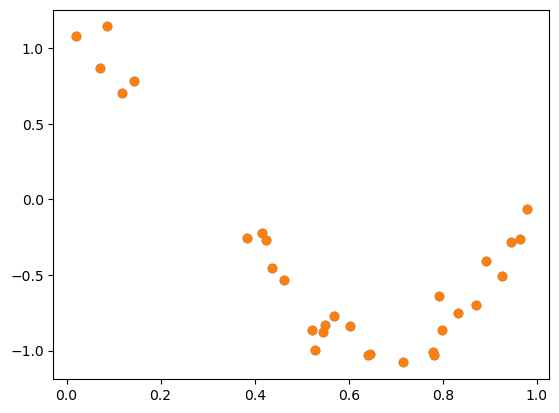

In [31]:
plt.scatter(X, y)
plt.show()


Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE 는 0.40772896250986845 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 는 0.0432087498723184 입니다.

Degree 15 회귀 계수는 [-2.98294000e+03  1.03899850e+05 -1.87416981e+06  2.03717199e+07
 -1.44874017e+08  7.09319141e+08 -2.47067173e+09  6.24564702e+09
 -1.15677216e+10  1.56895933e+10 -1.54007040e+10  1.06457993e+10
 -4.91381016e+09  1.35920643e+09 -1.70382078e+08] 입니다.
Degree 15 MSE 는 182581084.8263125 입니다.


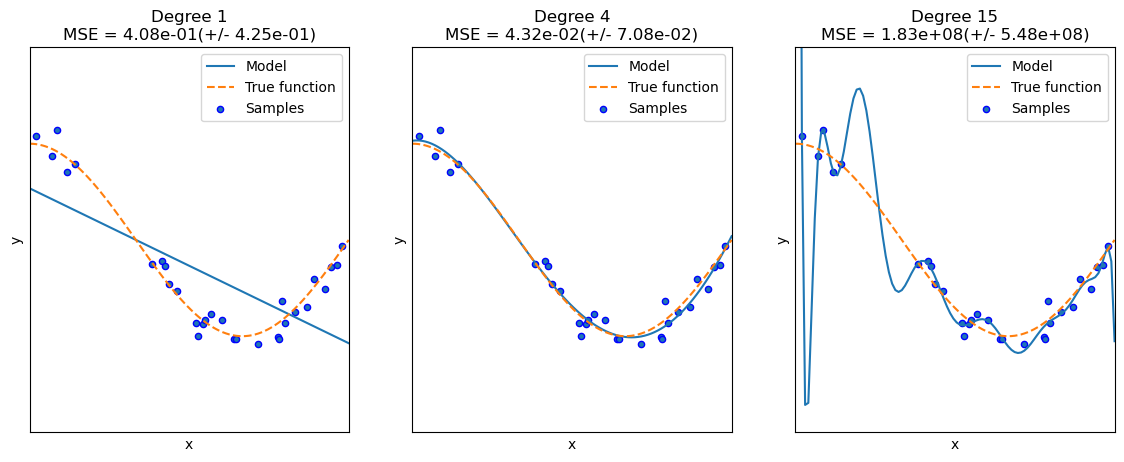

In [32]:
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

# 다항 회귀의 차수(degree)를 1, 4, 15로 각각 변화시키면서 비교합니다.
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())
    
    # 개별 degree별로 Polynomial 변환합니다.
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1, 1), y)
    
    # 교차 검증으로 다항 회귀를 평가합니다.
    scores = cross_val_score(pipeline, X.reshape(-1, 1), y, scoring="neg_mean_squared_error", cv=10)
    # Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1*np.mean(scores)))
          
    # 0 부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
    # 테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다.
    X_test = np.linspace(0, 1, 100)
    # 예측값 곡선
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    # 실제 값 곡선
    plt.plot(X_test, true_fun(X_test), '--', label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x"); plt.ylabel("y"); plt.xlim((0, 1)); plt.ylim((-2, 2)); plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std()))
    
plt.show()

* **결론**

  결국 좋은 예측 모델은 Degree 1과 같이 학습 데이터의 패턴을 지나치게 단순화한 과소적합 모델도 아니고
  Degree 15와 같이 모든 학습 데이터의 패턴을 하나하나 감안한 지나치게 복잡한 과적합 모델도 아닌
  학습 데이터의 패턴을 잘 반영하면서도 복잡하지 않은 균형 잡힌 (Balanced) 모델을 의미합니다.

### 편향 - 분산 트레이드오프(Bias-Variance Trade off)
* 교재에서 읽어보기